# Harmonic Polylogarithms, Multiple Polylogarithms, and Multiple Zeta Values

This notebook gives an interactive overview of three closely related families of
special functions that appear throughout modern particle physics (Feynman integrals)
and number theory.

| Symbol | Name | Depth | Key parameter |
|--------|------|-------|---------------|
| $H(\vec{m};\, x)$ | Harmonic Polylogarithm (HPL) | $n = \|\vec{m}\|$ | $x \in [0,1]$ |
| $\mathrm{Li}(\vec{m};\, \vec{x})$ | Multiple Polylogarithm (MPL) | $n = \|\vec{m}\|$ | $x_i \in [0,1]$ |
| $Z(\vec{m})$ | Multiple Zeta Value (MZV) | $k$ | — |

All three are implemented in `src/hpl.py` via `mpmath` (arbitrary precision)
and a `sympy` symbolic layer.

## 0  Setup

In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sympy as sp
from mpmath import mp, mpf, mpc, log, polylog, zeta, pi, nstr
import mpmath

from hpl import (HPL, n_hpl, n_mzv, shuffle_expand, stuffle_expand, hpl_at_one, harmonic_polylog, multiple_zeta_value, multiple_polylog, _n_nielsen_S, _n_hpl_dispatch_v2)

mp.dps = 30
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print(f"mpmath dps = {mp.dps}  |  sympy {sp.__version__}")


mpmath dps = 30  |  sympy 1.14.0


---
## 1  Harmonic Polylogarithms (HPL)

### Definition
HPLs are defined by iterated integration:
$$H(m_1, m_2, \ldots, m_n;\, x) = \int_0^x f(m_1, t)\; H(m_2, \ldots, m_n;\, t)\, dt, \qquad H(\,;\, x)=1$$
with weight functions
$$f(+1, t) = \frac{1}{1-t}, \quad f(-1, t) = \frac{1}{1+t}, \quad f(0, t) = \frac{1}{t}.$$

The **weight** $n = |\vec m|$ counts integrations.  At weight 1 they reduce to
elementary logarithms; higher weights encode dilogarithms, Nielsen functions,
and transcendental numbers not expressible in simpler terms.

### Abbreviated notation
Multi-digit entries encode iterated kernels compactly:
- $H(2;\, x) = \mathrm{Li}_2(x)$ — entry $2$ expands to two parameters $(0, 1)$
- $H(-2;\, x) = -\mathrm{Li}_2(-x)$
- $H(m, \underbrace{1,\ldots,1}_k;\, x) = S_{m-1,\, k+1}(x)$ (Nielsen polylogarithm)

### Key algebraic structure
HPLs satisfy two product identities:
- **Shuffle**: $H(\vec a;\, x)\cdot H(\vec b;\, x) = \sum_{\sigma\in\text{Sh}(a,b)} H(\sigma;\, x)$
- **Value at 1**: $H(\vec m;\, 1) = Z(\vec m)$ when $m_1 \geq 2$ (Multiple Zeta Value)


### 1.1  Weight-1: pure logarithms

In [5]:
x_sym = sp.Symbol('x', positive=True)
print("Symbolic form of weight-1 HPLs:")
for mm, formula in [((1,), "-log(1-x)"), ((-1,), "log(1+x)"), ((0,), "log(x)")]:
    expr = sp.expand_func(HPL(mm, x_sym))
    print(f"  H({list(mm)};  x)  =  {expr}")

print()
print("Numerical values at x = 0.5 (30 d.p.):")
x0 = mpf('0.5')
rows = [
    ((1,),  log(1-x0) * (-1),  "log(2)"),
    ((-1,), log(1+x0),         "log(3/2)"),
    ((0,),  log(x0),           "log(1/2) = -log(2)"),
]
for mm, ref, desc in rows:
    val = n_hpl(mm, x0)
    print(f"  H({list(mm)};  0.5) = {nstr(val, 22)}  [{desc}]")


Symbolic form of weight-1 HPLs:
  H([1];  x)  =  -log(1 - x)
  H([-1];  x)  =  log(x + 1)
  H([0];  x)  =  log(x)

Numerical values at x = 0.5 (30 d.p.):
  H([1];  0.5) = (0.6931471805599453094172 + 0.0j)  [log(2)]
  H([-1];  0.5) = (0.405465108108164381978 + 0.0j)  [log(3/2)]
  H([0];  0.5) = (-0.6931471805599453094172 + 0.0j)  [log(1/2) = -log(2)]


### 1.2  Weight-2: dilogarithms and mixed-sign

In [3]:
print("Weight-2 HPL values:")
print()
x0 = mpf('0.5')
x3 = mpf('0.3')
rows = [
    ((2,),   x0, "Li_2(1/2)"),
    ((-2,),  x0, "-Li_2(-1/2)"),
    ((1,1),  x0, "log^2(1/2)/2"),
    ((1,-1), x3, "integral definition"),
    ((-1,1), x3, "integral definition"),
    ((2,-1), x3, "integral definition"),
]
for mm, xv, desc in rows:
    val = n_hpl(mm, xv)
    print(f"  H({str(list(mm)):12s}; {float(xv):.1f})  =  {nstr(val,20):28s}  # {desc}")

print()
print("Known identity:  H(1,1; x) = log^2(1-x)/2")
v1  = n_hpl((1,1), x0)
v2  = log(1-x0)**2 / 2
print(f"  n_hpl: {nstr(v1, 20)}")
print(f"  formula: {nstr(v2, 20)}")
print(f"  match: {abs(v1-v2) < mpf(10)**(-25)}")


Weight-2 HPL values:

  H([2]         ; 0.5)  =  (0.5822405264650125059 + 0.0j)  # Li_2(1/2)
  H([-2]        ; 0.5)  =  (0.44841420692364620244 + 0.0j)  # -Li_2(-1/2)
  H([1, 1]      ; 0.5)  =  (0.24022650695910071233 + 0.0j)  # log^2(1/2)/2
  H([1, -1]     ; 0.3)  =  (0.051593646463082878369 + 0.0j)  # integral definition
  H([-1, 1]     ; 0.3)  =  (0.041985112857386248094 + 0.0j)  # integral definition
  H([2, -1]     ; 0.3)  =  (0.024498179719051284213 + 0.0j)  # integral definition

Known identity:  H(1,1; x) = log^2(1-x)/2
  n_hpl: (0.24022650695910071233 + 0.0j)
  formula: 0.24022650695910071233
  match: True


### 1.3  Arbitrary precision

In [4]:
print("Precision scales with mp.dps:\n")
for dps in [15, 30, 50, 80]:
    mp.dps = dps
    val = n_hpl((1, 2), mpf('0.5'))
    print(f"  dps={dps:2d}: H(1,2; 0.5) = {nstr(val, dps-2)}")

mp.dps = 30


Precision scales with mp.dps:

  dps=15: H(1,2; 0.5) = (0.2140723708667 + 0.0j)
  dps=30: H(1,2; 0.5) = (0.2140723708667062274342131253 + 0.0j)
  dps=50: H(1,2; 0.5) = (0.214072370866706227434213125349690417557713933372 + 0.0j)
  dps=80: H(1,2; 0.5) = (0.214072370866706227434213125349690417557713933372433630430407791370324797696307 + 0.0j)


### 1.4  Visualisation – HPL families

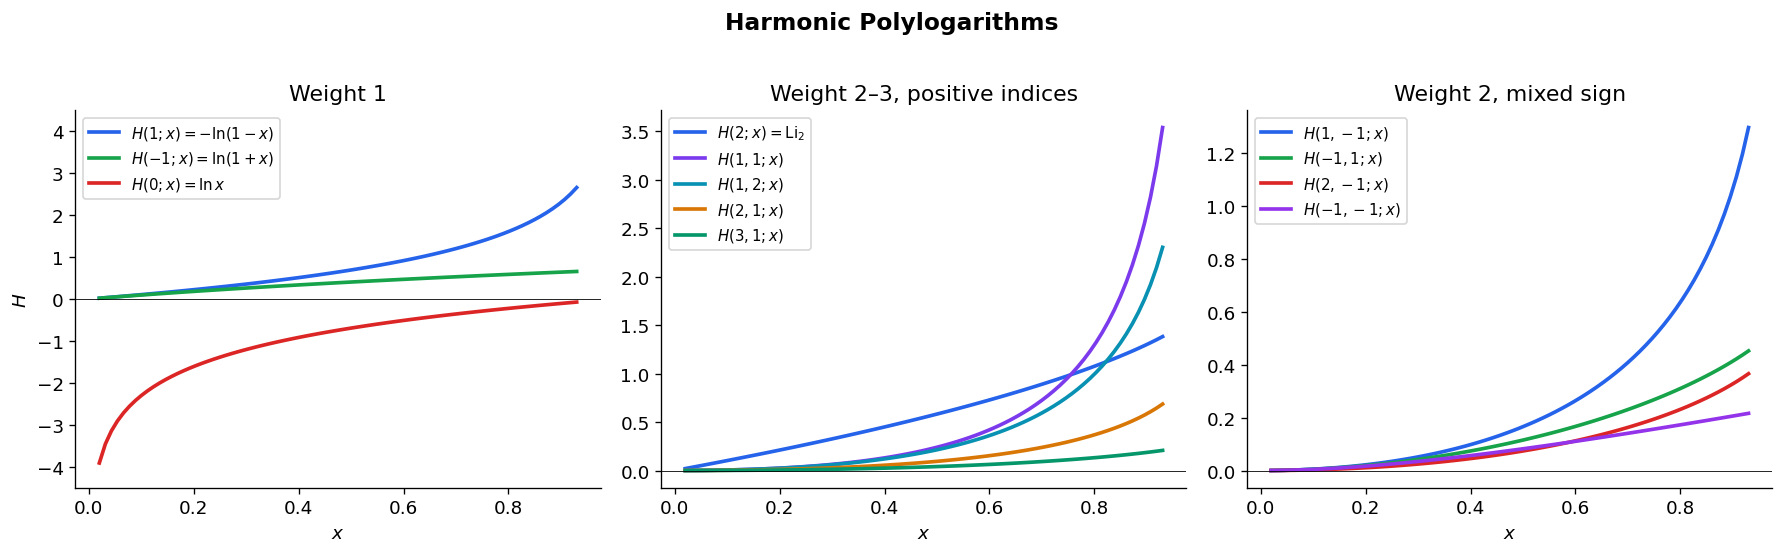

In [5]:
mp.dps = 18
xs = np.linspace(0.02, 0.93, 80)

def curve(mm, xs):
    return [float(n_hpl(mm, mpf(str(x))).real) for x in xs]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Weight-1
ax = axes[0]
for mm, lbl, c in [((1,), r"$H(1;x)=-\ln(1-x)$", "#2563eb"),
                   ((-1,),r"$H(-1;x)=\ln(1+x)$", "#16a34a"),
                   ((0,), r"$H(0;x)=\ln x$",      "#dc2626")]:
    ax.plot(xs, curve(mm, xs), label=lbl, color=c, lw=2.2)
ax.set(title="Weight 1", xlabel="$x$", ylabel="$H$", ylim=(-4.5, 4.5))
ax.axhline(0, color='k', lw=0.5); ax.legend(fontsize=9)

# Weight-2/3 positive
ax = axes[1]
for mm, lbl, c in [((2,),  r"$H(2;x)=\mathrm{Li}_2$", "#2563eb"),
                   ((1,1), r"$H(1,1;x)$",               "#7c3aed"),
                   ((1,2), r"$H(1,2;x)$",               "#0891b2"),
                   ((2,1), r"$H(2,1;x)$",               "#d97706"),
                   ((3,1), r"$H(3,1;x)$",               "#059669")]:
    ax.plot(xs, curve(mm, xs), label=lbl, color=c, lw=2.2)
ax.set(title="Weight 2–3, positive indices", xlabel="$x$")
ax.axhline(0, color='k', lw=0.5); ax.legend(fontsize=9)

# Mixed-sign
ax = axes[2]
for mm, lbl, c in [((1,-1),  r"$H(1,-1;x)$",  "#2563eb"),
                   ((-1,1),  r"$H(-1,1;x)$",   "#16a34a"),
                   ((2,-1),  r"$H(2,-1;x)$",   "#dc2626"),
                   ((-1,-1), r"$H(-1,-1;x)$",  "#9333ea")]:
    ax.plot(xs, curve(mm, xs), label=lbl, color=c, lw=2.2)
ax.set(title="Weight 2, mixed sign", xlabel="$x$")
ax.axhline(0, color='k', lw=0.5); ax.legend(fontsize=9)

fig.suptitle("Harmonic Polylogarithms", fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig("hpl_families.png", dpi=130, bbox_inches='tight')
plt.show()
mp.dps = 30


### 1.5  Shuffle product

In [6]:
print("Shuffle products (symbolic):\n")
for mm1, mm2 in [((1,),(1,)), ((1,),(2,)), ((1,1),(1,)), ((2,),(1,-1))]:
    result = dict(shuffle_expand(mm1, mm2))
    terms = sorted(result.items())
    rhs = " + ".join(
        f"{c}·H({list(m)};x)" if c != 1 else f"H({list(m)};x)"
        for m, c in terms
    )
    print(f"  H({list(mm1)};x) · H({list(mm2)};x)  =  {rhs}")

print()
x0 = mpf('0.5')
lhs = n_hpl((1,), x0) * n_hpl((2,), x0)
rhs = n_hpl((1,2), x0) + 2*n_hpl((2,1), x0)
print(f"Numerical check at x=0.5:")
print(f"  H(1)·H(2)           = {nstr(lhs, 18)}")
print(f"  H(1,2) + 2·H(2,1)   = {nstr(rhs, 18)}")
print(f"  match: {abs(lhs-rhs) < mpf(10)**(-25)}")


Shuffle products (symbolic):

  H([1];x) · H([1];x)  =  2·H([1, 1];x)
  H([1];x) · H([2];x)  =  H([1, 2];x) + 2·H([2, 1];x)
  H([1, 1];x) · H([1];x)  =  3·H([1, 1, 1];x)
  H([2];x) · H([1, -1];x)  =  H([1, -2, 1];x) + H([1, -1, 2];x) + H([1, 2, -1];x) + H([2, -1, 1];x) + 2·H([2, 1, -1];x)

Numerical check at x=0.5:
  H(1)·H(2)           = (0.403578379326961639 + 0.0j)
  H(1,2) + 2·H(2,1)   = (0.403578379326961639 + 0.0j)
  match: True


### 1.6  Rewrite HPL expressions into an equivalent form expressed using simpler or more canonical functions

In [4]:
x_sym = sp.Symbol('x')
print("Symbolic HPL expansions:\n")
for mm in [(1,), (-1,), (2,), (-2,), (2,-1), (1,2)]:
    expr = sp.expand_func(HPL(mm, x_sym))
    if not hasattr(expr, 'mm'):
        print(f"  H({list(mm)};x)  =  {expr}")

print("\nNielsen generalised polylogarithm  H(m, 1^k; x) = S(m-1, k+1, x):")
for mm, a, n in [((2,1), 1, 2), ((2,1,1), 1, 3), ((3,1), 2, 2), ((3,1,1), 2, 3)]:
    xv = mpf('0.4')
    val_hpl = n_hpl(mm, xv)
    val_s   = _n_nielsen_S(a, n, xv)
    print(f"  H({list(mm)};0.4) = S({a},{n};0.4) = {nstr(val_hpl,15)} (err={float(abs(val_hpl-val_s)):.2e})")


Symbolic HPL expansions:

  H([1];x)  =  -log(1 - x)
  H([-1];x)  =  log(x + 1)
  H([2];x)  =  polylog(2, x)
  H([-2];x)  =  -polylog(2, -x)
  H([2, -1];x)  =  (log(64)*log(x + 1) - 6*log(2)**2 + pi**2)*log(x + 1)/12 + log(x + 1)*polylog(2, x) - polylog(3, x) - polylog(3, x/(x + 1)) + polylog(3, 2*x/(x + 1)) - polylog(3, x/2 + 1/2) - pi**2*log(4)/24 + log(2)**3/6 + 7*zeta(3)/8
  H([1, 2];x)  =  -log(1 - x)*polylog(2, 1 - x) - pi**2*log(1 - x)/6 + 2*polylog(3, 1 - x) - 2*zeta(3)

Nielsen generalised polylogarithm  H(m, 1^k; x) = S(m-1, k+1, x):
  H([2, 1];0.4) = S(1,2;0.4) = (0.0548349172502481 + 0.0j) (err=1.85e-32)
  H([2, 1, 1];0.4) = S(1,3;0.4) = (0.00608310297866017 + 0.0j) (err=7.70e-34)
  H([3, 1];0.4) = S(2,2;0.4) = (0.0245192857707796 + 0.0j) (err=6.56e-31)
  H([3, 1, 1];0.4) = S(2,3;0.4) = (0.00175587507594356 + 0.0j) (err=0.00e+00)


In [2]:
x_sym = sp.Symbol('x')
sp.expand_func(HPL(sp.Tuple(2, -1), x_sym))

(log(64)*log(x + 1) - 6*log(2)**2 + pi**2)*log(x + 1)/12 + log(x + 1)*polylog(2, x) - polylog(3, x) - polylog(3, x/(x + 1)) + polylog(3, 2*x/(x + 1)) - polylog(3, x/2 + 1/2) - pi**2*log(4)/24 + log(2)**3/6 + 7*zeta(3)/8

---
## 2  Multiple Polylogarithms (MPL)

### Definition
$$\mathrm{Li}(m_1,\ldots,m_k;\; x_1,\ldots,x_k)
   = \sum_{n_1 > n_2 > \cdots > n_k \geq 1}
     \frac{x_1^{n_1}}{n_1^{m_1}} \cdots \frac{x_k^{n_k}}{n_k^{m_k}}$$

The **classical polylogarithm** $\mathrm{Li}_s(z)$ is the depth-1 case $k=1$.

The **Multiple Zeta Values** arise at $x_i = 1$:
$$Z(m_1,\ldots,m_k) = \mathrm{Li}(m_1,\ldots,m_k;\, \underbrace{1,\ldots,1}_k)$$

HPLs are MPLs restricted to $x_i \in \{0, 1, -1\}$.


### 2.1  Classical polylogarithm Li_s(x)

In [8]:
print("Li_s(x) = H(s; x)  for integer s >= 1:")
x0 = mpf('0.5')
for s in range(1, 8):
    val = n_hpl((s,), x0)
    print(f"  Li_{s}(0.5) = {nstr(val, 22)}")

print()
print("Known identity:  Li_2(1/2) = pi^2/12 - (log 2)^2/2")
v = n_hpl((2,), mpf('0.5'))
ref = pi**2/12 - log(mpf(2))**2/2
print(f"  Li_2(1/2)           = {nstr(v, 22)}")
print(f"  pi^2/12-log^2(2)/2  = {nstr(ref, 22)}")
print(f"  match: {abs(v-ref) < mpf(10)**(-28)}")


Li_s(x) = H(s; x)  for integer s >= 1:
  Li_1(0.5) = (0.6931471805599453094172 + 0.0j)
  Li_2(0.5) = (0.5822405264650125059027 + 0.0j)
  Li_3(0.5) = (0.5372131936080402009406 + 0.0j)
  Li_4(0.5) = (0.5174790616738993863308 + 0.0j)
  Li_5(0.5) = (0.5084005792422687074591 + 0.0j)
  Li_6(0.5) = (0.50409539780398855069 + 0.0j)
  Li_7(0.5) = (0.5020145633247084945675 + 0.0j)

Known identity:  Li_2(1/2) = pi^2/12 - (log 2)^2/2
  Li_2(1/2)           = (0.5822405264650125059027 + 0.0j)
  pi^2/12-log^2(2)/2  = 0.5822405264650125059027
  match: True


### 2.2  Visualisation – Li_s(x) for orders 1–6

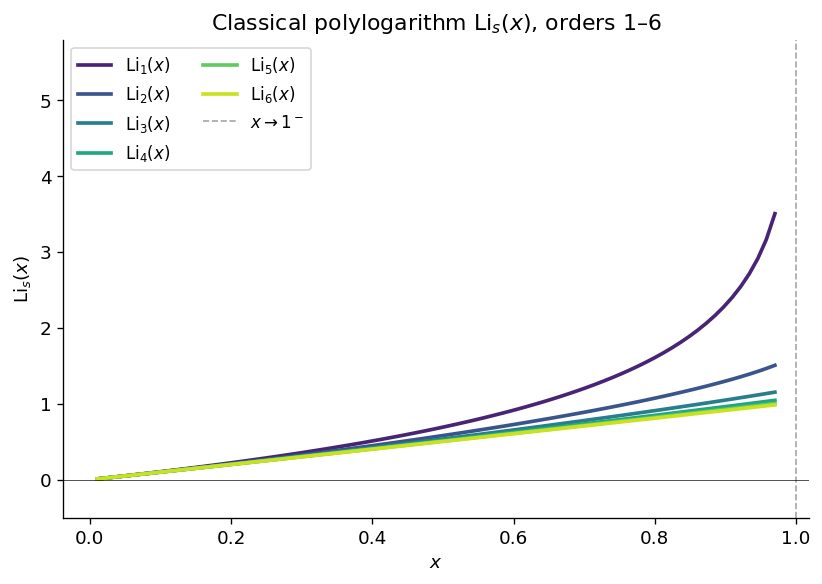

In [9]:
mp.dps = 18
xs = np.linspace(0.01, 0.97, 80)

fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.92, 6))
for s, color in zip(range(1, 7), colors):
    ys = [float(n_hpl((s,), mpf(str(x))).real) for x in xs]
    ax.plot(xs, ys, label=f"$\mathrm{{Li}}_{s}(x)$", color=color, lw=2.2)
ax.axvline(1.0, color='gray', lw=1, ls='--', alpha=0.7, label='$x\\to 1^-$')
ax.axhline(0,   color='k', lw=0.4)
ax.set(xlabel="$x$", ylabel="$\mathrm{Li}_s(x)$",
       title="Classical polylogarithm $\mathrm{Li}_s(x)$, orders 1–6",
       ylim=(-0.5, 5.8))
ax.legend(ncol=2, fontsize=10)
fig.tight_layout()
plt.savefig("polylog_orders.png", dpi=130, bbox_inches='tight')
plt.show()
mp.dps = 30


### 2.3  Depth-2 MPL: Li(1,1; x, y)

In [10]:
mp.dps = 20
print("Li(1,1; x, y) — depth-2 MPL:")
for x_val, y_val in [(0.3, 0.5), (0.5, 0.5), (0.7, 0.3), (0.8, 0.8), (0.9, 0.1)]:
    val = multiple_polylog((1,1), (mpf(str(x_val)), mpf(str(y_val))))
    print(f"  Li(1,1; {x_val}, {y_val}) = {nstr(val, 16)}")

print()
print("Limit:  Li(2,1; 1,1) = Z(2,1) = zeta(3) =", nstr(n_mzv((2,1)), 20))
mp.dps = 30


Li(1,1; x, y) — depth-2 MPL:
  Li(1,1; 0.3, 0.5) = (0.02991960068110097 + 0.0j)
  Li(1,1; 0.5, 0.5) = (0.1064001874177344 + 0.0j)
  Li(1,1; 0.7, 0.3) = (0.1643480535459871 + 0.0j)
  Li(1,1; 0.8, 0.8) = (0.9001321848165502 + 0.0j)
  Li(1,1; 0.9, 0.1) = (0.1455137408981379 + 0.0j)

Limit:  Li(2,1; 1,1) = Z(2,1) = zeta(3) = 1.2020569031595942854


### 2.4  Heatmap – Li(2,1; x, y)

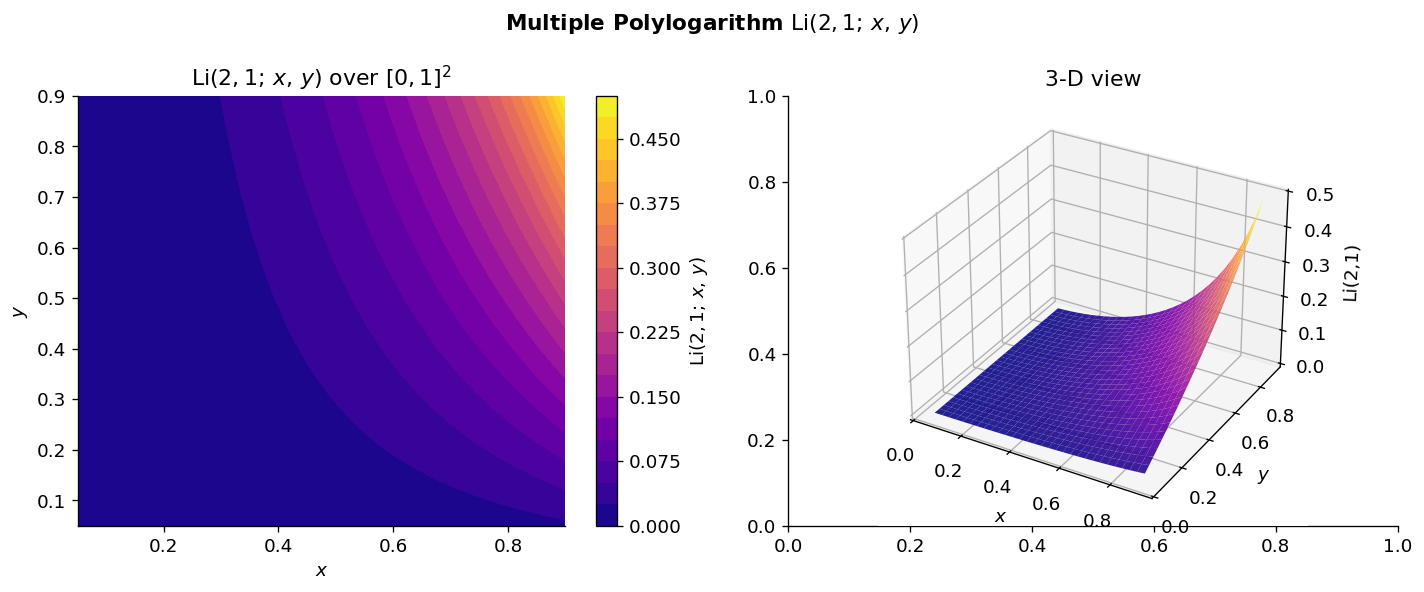

Approaches Z(2,1)=zeta(3)≈1.2020569 as x,y→1⁻


In [11]:
mp.dps = 14
N = 30
xg = np.linspace(0.05, 0.90, N)
yg = np.linspace(0.05, 0.90, N)
Z  = np.zeros((N, N))
for i, yv in enumerate(yg):
    for j, xv in enumerate(xg):
        try:
            v = multiple_polylog((2,1), (mpf(str(xv)), mpf(str(yv))))
            Z[i,j] = float(v.real)
        except Exception:
            Z[i,j] = float('nan')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].contourf(xg, yg, Z, levels=22, cmap='plasma')
plt.colorbar(im, ax=axes[0], label="$\mathrm{Li}(2,1;\,x,\,y)$")
axes[0].set(xlabel="$x$", ylabel="$y$",
            title="$\mathrm{Li}(2,1;\,x,\,y)$ over $[0,1]^2$")

# 3-D perspective
from mpl_toolkits.mplot3d import Axes3D
Xm, Ym = np.meshgrid(xg, yg)
ax3 = fig.add_subplot(122, projection='3d')
ax3.plot_surface(Xm, Ym, Z, cmap='plasma', alpha=0.9, linewidth=0)
ax3.set(xlabel="$x$", ylabel="$y$", zlabel="Li(2,1)",
        title="3-D view")

fig.suptitle("Multiple Polylogarithm $\mathrm{Li}(2,1;\,x,\,y)$",
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig("mpl_heatmap.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"Approaches Z(2,1)=zeta(3)≈{nstr(n_mzv((2,1)),8)} as x,y→1⁻")
mp.dps = 30


---
## 3  Multiple Zeta Values (MZV)

### Definition
$$Z(m_1, m_2, \ldots, m_k)
  = \sum_{n_1 > n_2 > \cdots > n_k \geq 1}
    \frac{1}{n_1^{m_1}\, n_2^{m_2} \cdots n_k^{m_k}}, \qquad m_1 \geq 2$$

The **weight** is $w = \sum m_i$ and the **depth** is $k$.

### Special values
| Identity | Value |
|----------|-------|
| $Z(2n)$  | $(-1)^{n+1}\,(2\pi)^{2n} B_{2n}/(2\,(2n)!)$ |
| $Z(2,1)$ | $\zeta(3)$ (Euler's identity) |
| $Z(3,1)$ | $\pi^4/360$ |
| $Z(2,\underbrace{1,\ldots,1}_{n-1})$ | $\zeta(n+1)$ |
| $Z(\underbrace{2,\ldots,2}_n)$ | $2(2\pi)^{2n}/(2n+1)!\cdot 2^{-(2n+1)}$ |

### Stuffle (quasi-shuffle) product
$$Z(\vec a)\cdot Z(\vec b) = \sum_{\text{stuffles}} Z(\vec c)$$
Unlike the shuffle product, the stuffle allows *coincident* positions to merge with
the kernel $m_i + m_j$.


### 3.1  Depth-1: Riemann zeta

In [12]:
mp.dps = 30
print("Depth-1 MZV = Riemann zeta values:\n")
for w in range(2, 10):
    val = n_mzv((w,))
    if w % 2 == 0:
        # compare with pi^w formula
        berns = {2: mpf(1)/6, 4: mpf(-1)/30, 6: mpf(1)/42,
                 8: mpf(-1)/30, 10: mpf(5)/66}
        if w in berns:
            B = berns[w]
            closed = (-1)**(w//2+1) * (2*pi)**w * B / (2 * mpmath.factorial(w))
            tag = f"  = {nstr(closed,15)} (pi formula)"
        else:
            tag = ""
    else:
        tag = "  (no known pi-closed form)" if w == 3 else ""
    print(f"  Z({w}) = {nstr(val, 22)}{tag}")


Depth-1 MZV = Riemann zeta values:

  Z(2) = 1.644934066848226436472  = 1.64493406684823 (pi formula)
  Z(3) = 1.2020569031595942854  (no known pi-closed form)
  Z(4) = 1.082323233711138191516  = 1.08232323371114 (pi formula)
  Z(5) = 1.036927755143369926331
  Z(6) = 1.017343061984449139715  = 1.01734306198445 (pi formula)
  Z(7) = 1.00834927738192282684
  Z(8) = 1.004077356197944339379  = 1.00407735619794 (pi formula)
  Z(9) = 1.002008392826082214418


### 3.2  Depth-2 and Euler's identity

In [13]:
mp.dps = 30
print("Depth-2 MZV:\n")
pairs = [(2,1),(3,1),(2,2),(3,2),(4,1),(2,3)]
for mm in pairs:
    val = n_mzv(mm)
    print(f"  Z{list(mm)} = {nstr(val, 22)}")

print()
print("Euler's identity:  Z(2,1) = Z(3) = zeta(3)")
print(f"  Z(2,1) = {nstr(n_mzv((2,1)), 22)}")
print(f"  Z(3)   = {nstr(n_mzv((3,)),  22)}")
print(f"  match: {abs(n_mzv((2,1)) - n_mzv((3,))) < mpf(10)**(-28)}")
print()
print("Z(3,1) = pi^4/360:")
print(f"  Z(3,1)  = {nstr(n_mzv((3,1)), 22)}")
print(f"  pi^4/360= {nstr(pi**4/360, 22)}")
print(f"  match: {abs(n_mzv((3,1)) - pi**4/360) < mpf(10)**(-28)}")


Depth-2 MZV:

  Z[2, 1] = 1.2020569031595942854
  Z[3, 1] = 0.270580808427784547879
  Z[2, 2] = 0.811742425283353643637
  Z[3, 2] = 0.2288103976033537597687
  Z[4, 1] = 0.09655115998944373446565
  Z[2, 3] = 0.711566197550572432097

Euler's identity:  Z(2,1) = Z(3) = zeta(3)
  Z(2,1) = 1.2020569031595942854
  Z(3)   = 1.2020569031595942854
  match: True

Z(3,1) = pi^4/360:
  Z(3,1)  = 0.270580808427784547879
  pi^4/360= 0.270580808427784547879
  match: True


### 3.3  Stuffle product

In [14]:
print("Stuffle products:\n")
for mm1, mm2 in [((2,),(2,)), ((2,),(3,)), ((3,),(3,)), ((2,1),(2,))]:
    result = dict(stuffle_expand(mm1, mm2))
    terms = sorted(result.items())
    rhs = " + ".join(
        f"{c}·Z({list(m)})" if c != 1 else f"Z({list(m)})"
        for m, c in terms
    )
    print(f"  Z({list(mm1)}) · Z({list(mm2)})  =  {rhs}")

print()
z2 = n_mzv((2,)); z22 = n_mzv((2,2)); z4 = n_mzv((4,))
print(f"Numerical check  Z(2)^2 = 2·Z(2,2) + Z(4):")
print(f"  Z(2)^2          = {nstr(z2**2, 18)}")
print(f"  2·Z(2,2)+Z(4)   = {nstr(2*z22+z4, 18)}")
print(f"  match: {abs(z2**2 - (2*z22+z4)) < mpf(10)**(-25)}")


Stuffle products:

  Z([2]) · Z([2])  =  2·Z([2, 2]) + Z([4])
  Z([2]) · Z([3])  =  Z([2, 3]) + Z([3, 2]) + Z([5])
  Z([3]) · Z([3])  =  2·Z([3, 3]) + Z([6])
  Z([2, 1]) · Z([2])  =  Z([2, 1, 2]) + 2·Z([2, 2, 1]) + Z([2, 3]) + Z([4, 1])

Numerical check  Z(2)^2 = 2·Z(2,2) + Z(4):
  Z(2)^2          = 2.70580808427784548
  2·Z(2,2)+Z(4)   = 2.70580808427784548
  match: True


### 3.4  All-twos formula

In [15]:
mp.dps = 30
print("Z(2,...,2) with n entries:\n")
print(f"  {'n':>2}  {'Z(2^n)':>28}  formula match")
print("  " + "-"*50)
for n in range(1, 8):
    mm = (2,)*n
    zv = n_mzv(mm)
    formula = 2*(2*pi)**(2*n) / mpmath.factorial(2*n+1) * mpf('0.5')**(2*n+1)
    ok = abs(zv - formula) < mpf(10)**(-25)
    print(f"  {n:>2}  {nstr(zv,22):>28}  {ok}")


Z(2,...,2) with n entries:

   n                        Z(2^n)  formula match
  --------------------------------------------------
   1       1.644934066848226436472  True
   2       0.811742425283353643637  True
   3      0.1907518241220842136965  True
   4     0.02614784781765480050465  True
   5    0.002346081035455823637509  True
   6   0.0001484287930310710036849  True
   7  0.000006975873661656380474534  True


### 3.5  MZV landscape visualisation

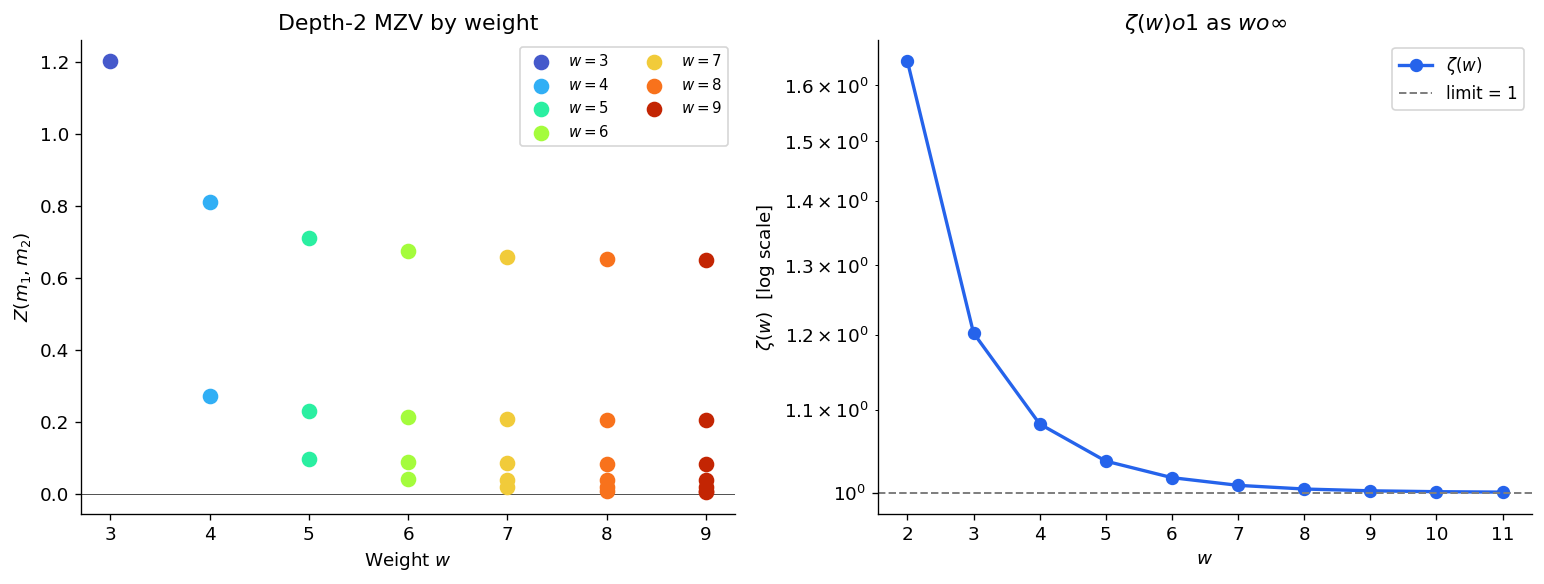

In [16]:
mp.dps = 18
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: depth-2 scatter by weight
ax = axes[0]
colors_w = plt.cm.turbo(np.linspace(0.1, 0.9, 7))
for idx, w in enumerate(range(3, 10)):
    vals = []
    for m1 in range(2, w):
        m2 = w - m1
        if m2 >= 1:
            vals.append(float(n_mzv((m1, m2)).real))
    if vals:
        ax.scatter([w]*len(vals), vals, color=colors_w[idx], s=70,
                   zorder=3, label=f"$w={w}$")
ax.set(xlabel="Weight $w$", ylabel="$Z(m_1,m_2)$",
       title="Depth-2 MZV by weight")
ax.axhline(0, color='k', lw=0.4)
ax.legend(fontsize=9, ncol=2)

# Right: zeta(w) → 1
ax2 = axes[1]
ws_arr = list(range(2, 12))
zv_arr = [float(n_mzv((w,)).real) for w in ws_arr]
ax2.semilogy(ws_arr, zv_arr, 'o-', color='#2563eb', lw=2, ms=7,
             label=r"$\zeta(w)$")
ax2.axhline(1.0, color='gray', lw=1.2, ls='--', label='limit = 1')
ax2.set(xlabel="$w$", ylabel="$\zeta(w)$  [log scale]",
        title=r"$\zeta(w) 	o 1$ as $w	o\infty$")
ax2.legend(fontsize=10)
ax2.set_xticks(ws_arr)

fig.tight_layout()
plt.savefig("mzv_landscape.png", dpi=130, bbox_inches='tight')
plt.show()
mp.dps = 30


---
## 4  Identities and Connections

| Identity | Expression |
|----------|-----------|
| HPL at 1 | $H(\vec m;1) = Z(\vec m)$ when $m_1\ge2$ |
| Euler | $Z(2,1)=Z(3)=\zeta(3)$ |
| Sum formula | $\sum_{\substack{\vec m \text{ depth-}k \\ |\vec m|=w}} Z(\vec m) = \zeta(w)$ |
| All-twos | $Z(\underbrace{2,\ldots,2}_n) = \tfrac{2(2\pi)^{2n}}{(2n+1)!2^{2n+1}}$ |
| Nielsen | $H(m,\underbrace{1,\ldots,1}_k;x) = S(m-1,k+1,x)$ |


### 4.1  HPL values at x = 1 from precomputed table

In [17]:
mp.dps = 30
print("H(mm; 1) vs Z(mm) — precomputed table vs direct MZV:\n")
for mm in [(2,),(3,),(3,1),(2,1,1),(4,2,1)]:
    h1 = hpl_at_one(mm)
    zv = n_mzv(mm)
    err = float(abs(h1 - zv))
    print(f"  H({list(mm)};1) = {nstr(h1,18)}  |  Z = {nstr(zv,18)}  |  err={err:.2e}")


H(mm; 1) vs Z(mm) — precomputed table vs direct MZV:

  H([2];1) = (1.64493406684822644 + 0.0j)  |  Z = 1.64493406684822644  |  err=0.00e+00
  H([3];1) = (1.20205690315959429 + 0.0j)  |  Z = 1.20205690315959429  |  err=0.00e+00
  H([3, 1];1) = (0.270580808427784548 + 0.0j)  |  Z = 0.270580808427784548  |  err=9.86e-32
  H([2, 1, 1];1) = (1.08232323371113819 + 0.0j)  |  Z = 1.08232323371113819  |  err=0.00e+00
  H([4, 2, 1];1) = (0.00695284815272088649 + 0.0j)  |  Z = (0.00695262702469299938 + 0.0j)  |  err=2.21e-07


### 4.2  Sum formula for depth-2

In [18]:
mp.dps = 30
print("Sum formula: sum of all depth-2 weight-w MZV = zeta(w):\n")
for w in range(3, 9):
    total = sum(n_mzv((m1, w-m1)) for m1 in range(2, w) if w-m1 >= 1)
    zw    = n_mzv((w,))
    ok    = abs(total - zw) < mpf(10)**(-25)
    print(f"  weight {w}: sum = {nstr(total,18)}  zeta({w}) = {nstr(zw,18)}  match={ok}")


Sum formula: sum of all depth-2 weight-w MZV = zeta(w):

  weight 3: sum = 1.20205690315959429  zeta(3) = 1.20205690315959429  match=True
  weight 4: sum = 1.08232323371113819  zeta(4) = 1.08232323371113819  match=True
  weight 5: sum = 1.03692775514336993  zeta(5) = 1.03692775514336993  match=True
  weight 6: sum = 1.01734306198444914  zeta(6) = 1.01734306198444914  match=True
  weight 7: sum = 1.00834927738192283  zeta(7) = 1.00834927738192283  match=True
  weight 8: sum = 1.00407735619794434  zeta(8) = 1.00407735619794434  match=True


### 4.3  Performance benchmark

In [19]:
import time
mp.dps = 30
print(f"{'Case':45s}  {'ms/call':>8}")
print("-"*56)
cases = [
    ("H(1;    0.5)  weight-1 log",      (1,),    mpf('0.5')),
    ("H(2,1;  0.3)  fast series",       (2,1),   mpf('0.3')),
    ("H(2,-1; 0.3)  mixed-sign fast",   (2,-1),  mpf('0.3')),
    ("H(1,1,1;0.5)  all-equal",         (1,1,1), mpf('0.5')),
    ("H(2,1,1;0.4)  Nielsen S path",    (2,1,1), mpf('0.4')),
    ("H(3,1;  0.4)  Nielsen S",         (3,1),   mpf('0.4')),
    ("H(1,1;  0.9999) 1-x transform",   (1,1),   mpf('0.9999')),
]
for label, mm, xv in cases:
    N = 10
    t0 = time.perf_counter()
    for _ in range(N): n_hpl(mm, xv)
    ms = (time.perf_counter()-t0)/N*1000
    print(f"  {label:43s}  {ms:8.2f}")


Case                                            ms/call
--------------------------------------------------------
  H(1;    0.5)  weight-1 log                       0.01
  H(2,1;  0.3)  fast series                        1.73
  H(2,-1; 0.3)  mixed-sign fast                    1.73
  H(1,1,1;0.5)  all-equal                          0.02
  H(2,1,1;0.4)  Nielsen S path                     2.97
  H(3,1;  0.4)  Nielsen S                          2.29
  H(1,1;  0.9999) 1-x transform                    0.07


---
## 5  Complex arguments and extreme precision

HPLs extend analytically to $\mathbb{C} \setminus [1, \infty)$.
The library automatically handles:
- Complex $x$ via the direct backward-recurrence series
- Branch cuts via careful sign tracking
- Near-unity arguments via the $1-x$ symbolic transform


### 5.1  Complex argument

In [20]:
mp.dps = 30
z = mpc('0.5', '0.3')
print(f"HPL at x = {z}:\n")
for mm in [(1,), (2,), (1,1), (1,-1), (-1,1), (2,1)]:
    val = n_hpl(mm, z)
    print(f"  H({list(mm)};0.5+0.3i) = {nstr(val.real,14)} + {nstr(val.imag,14)}·i")

print()
print("Branch cut:  H(1;x) has a cut along [1, ∞)")
for x_val, label in [(mpc(2, 1e-14), "2+iε"), (mpc(2,-1e-14), "2-iε")]:
    h = n_hpl((1,), x_val)
    print(f"  H(1; {label}) = {nstr(h.real,12)} + {nstr(h.imag,12)}·i")
xa = mpc(2, 1e-14); xb = mpc(2, -1e-14)
disc = n_hpl((1,), xa) - n_hpl((1,), xb)
print(f"  Discontinuity: {nstr(disc,10)}")
print(f"  Expected +2πi: {nstr(mpc(0,1)*2*pi, 10)}")


HPL at x = (0.5 + 0.3j):

  H([1];0.5+0.3i) = 0.53940483068596 + 0.54041950027058·i
  H([2];0.5+0.3i) = 0.53096162960408 + 0.4034368241752·i
  H([1, 1];0.5+0.3i) = -0.00054783245267668 + 0.29150488904285·i
  H([1, -1];0.5+0.3i) = 0.051159569990396 + 0.202684284757·i
  H([-1, 1];0.5+0.3i) = 0.071451779256965 + 0.13351090398423·i
  H([2, 1];0.5+0.3i) = 0.0224906482114 + 0.11960489010014·i

Branch cut:  H(1;x) has a cut along [1, ∞)
  H(1; 2+iε) = -5.0e-29 + 3.14159265359·i
  H(1; 2-iε) = -5.0e-29 + -3.14159265359·i
  Discontinuity: (0.0 + 6.283185307j)
  Expected +2πi: (0.0 + 6.283185307j)


### 5.2  100-digit precision

In [21]:
mp.dps = 100
print("100-digit evaluation:")
val = n_hpl((2, 1), mpf('0.5'))
s   = nstr(val, 98)
print("  H(2,1; 0.5) =")
for i in range(0, len(s), 50):
    print(f"    {s[i:i+50]}")
print()
val2 = n_mzv((3,2))
s2   = nstr(val2, 98)
print("  Z(3,2) =")
for i in range(0, len(s2), 50):
    print(f"    {s2[i:i+50]}")
mp.dps = 30


100-digit evaluation:
  H(2,1; 0.5) =
    (0.09475300423012770572182500642030949148626887231
    77945848254986372470876882892772989638810048101294
    73 + 0.0j)

  Z(3,2) =
    0.228810397603353759768746148941688791932509342719
    88216022940710269322535861526445802691603150101547


## 6  Gallery – weight-3 HPL landscape

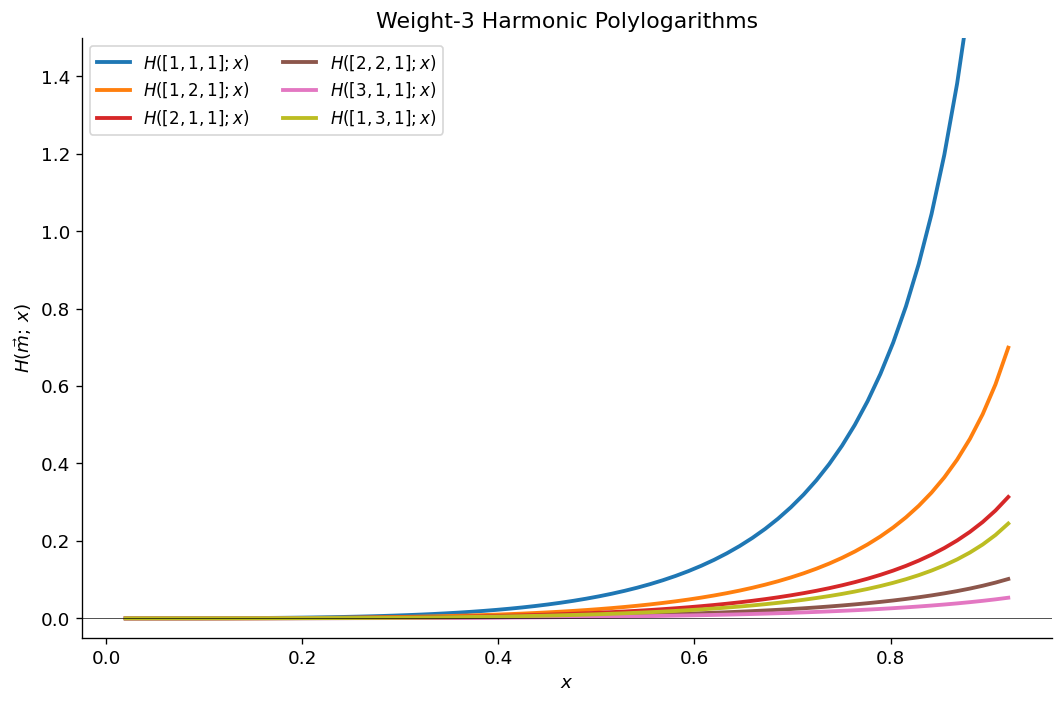

In [22]:
mp.dps = 18
xs = np.linspace(0.02, 0.92, 70)

selected = [(1,1,1),(1,2,1),(2,1,1),(2,2,1),(3,1,1),(1,3,1)]
colors = plt.cm.tab10(np.linspace(0, 0.85, len(selected)))

fig, ax = plt.subplots(figsize=(9, 6))
for mm, color in zip(selected, colors):
    ys = [float(n_hpl(mm, mpf(str(x))).real) for x in xs]
    ax.plot(xs, ys, label=f"$H({list(mm)};x)$", color=color, lw=2.3)

ax.axhline(0, color='k', lw=0.4)
ax.set(xlabel="$x$", ylabel="$H(\\vec m;\\, x)$",
       title="Weight-3 Harmonic Polylogarithms",
       ylim=(-0.05, 1.5))
ax.legend(fontsize=10, ncol=2, loc='upper left')
fig.tight_layout()
plt.savefig("weight3_hpl.png", dpi=130, bbox_inches='tight')
plt.show()
mp.dps = 30


---
## Summary

| Operation | Code | Result |
|-----------|------|--------|
| Weight-1 HPL | `n_hpl((1,), 0.5)` | $\log 2$ |
| Dilogarithm | `n_hpl((2,), 0.5)` | $\mathrm{Li}_2(1/2)$ |
| Mixed-sign | `n_hpl((2,-1), 0.3)` | fast series path |
| Near $x=1$ | `n_hpl((1,1), 0.9999)` | $1-x$ transform |
| MZV Euler | `n_mzv((2,1))` | $\zeta(3)$ |
| MZV closed-form | `n_mzv((3,1))` | $\pi^4/360$ |
| Expand | `sp.expand_func(HPL((2,-1), x))` | equivalent form expressed using simpler or more canonical functions |
| Shuffle | `shuffle_expand((1,),(2,))` | `{(1,2):1, (2,1):2}` |
| Stuffle | `stuffle_expand((2,),(2,))` | `{(2,2):2, (4,):1}` |
| Nielsen $S$ | `_n_nielsen_S(1, 3, 0.4)` | $S(1,3;0.4)$ |
| Arbitrary dps | `mp.dps=100; n_hpl(...)` | 100-digit precision |

**Key identities verified:**
- $Z(2,1) = \zeta(3)$ (Euler, depth-2 weight-3)
- $Z(3,1) = \pi^4/360$ (depth-2 weight-4)
- $Z(\underbrace{2,\ldots,2}_n) = 2(2\pi)^{2n}/(2n+1)!\cdot 2^{-(2n+1)}$
- Sum formula: $\sum_{|\vec m|=w,\,\text{depth-}k} Z(\vec m) = \zeta(w)$
